# Notebook 02 - Multimodal Relation Taxonomy & Final Dataset Policy

Notebook ini adalah lanjutan dari `01_dataset_integration_quality_audit.ipynb`.

Tujuan utama:
1. Membuat taxonomy relasi text-image yang lebih operasional untuk penelitian MABSA hotel.
2. Menentukan kebijakan pemakaian data untuk training, ablation, dan error analysis.
3. Membuat file policy level review, level image, dan level aspek.
4. Menyiapkan dasar metodologis untuk arsitektur relation-aware multimodal fusion.

Dataset input di Kaggle:
- `text_labelling.csv`
- `image_labelling.csv`

Output notebook:
- `/kaggle/working/mabsa_relation_policy_outputs/review_level_relation_policy.csv`
- `/kaggle/working/mabsa_relation_policy_outputs/image_level_relation_policy.csv`
- `/kaggle/working/mabsa_relation_policy_outputs/aspect_level_relation_matrix.csv`
- `/kaggle/working/mabsa_relation_policy_outputs/relation_policy_summary.json`
- `/kaggle/working/mabsa_relation_policy_outputs/methodology_notes_for_thesis.md`

Notebook ini **tidak mengubah file sumber**.

## Dasar Metodologi

Notebook ini dibuat berdasarkan kebutuhan metodologis MABSA, bukan hanya preprocessing teknis.

### 1. ABSA sebagai prediksi aspek dan polaritas

SemEval-2014 Task 4 mendefinisikan Aspect-Based Sentiment Analysis sebagai tugas untuk mengidentifikasi aspek dari suatu entitas dan sentimen terhadap aspek tersebut. Karena itu, audit dan policy tidak boleh hanya berbasis sentimen umum review, tetapi harus berbasis 7 aspek:

- Kamar
- Kebersihan
- Pelayanan
- Harga
- Lokasi
- Fasilitas
- Makanan

Referensi:
- Pontiki et al. (2014), SemEval-2014 Task 4: Aspect Based Sentiment Analysis. https://aclanthology.org/S14-2004/

### 2. MABSA membutuhkan interaksi text-image-aspect

MIMN memperkenalkan MABSA sebagai tugas fine-grained yang memperhatikan interaksi antara aspek, teks, dan gambar. Artinya, gambar tidak sekadar ditempel sebagai fitur tambahan, tetapi perlu dinilai apakah berhubungan dengan aspek yang sedang dibahas.

Referensi:
- Xu, Mao, & Chen (2019), Multi-Interactive Memory Network for Aspect Based Multimodal Sentiment Analysis. https://ojs.aaai.org/index.php/AAAI/article/view/3807

### 3. Gambar yang tidak relevan adalah noise multimodal

M2DF membahas bahwa banyak pasangan text-image dalam MABSA mengandung noisy visual context. Jika semua gambar digabung begitu saja, model bisa belajar sinyal visual yang tidak relevan. Karena itu, dataset perlu diberi relation tag agar eksperimen bisa membedakan data clean, noisy, contradiction, image-only, dan text-only.

Referensi:
- Zhao et al. (2023), M2DF: Multi-grained Multi-curriculum Denoising Framework for Multimodal Aspect-based Sentiment Analysis. https://aclanthology.org/2023.emnlp-main.561/

### 4. Relation-aware policy penting untuk arsitektur sistem

Output notebook ini akan menjadi dasar untuk:

- training utama pada data clean/correlated,
- relation-aware fusion untuk data noisy,
- ablation study text-only vs image-only vs multimodal,
- error analysis pada kasus kontradiktif,
- keputusan drop/manual review untuk data rusak.

### 1. Import Library, Persiapan Direktori Output, dan Konstanta


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
VALID_LABELS = {"Positif", "Negatif", "Netral", "None"}
POLAR_LABELS = {"Positif", "Negatif"}

TEXT_FILE_NAME = "text_labelling.csv"
IMAGE_FILE_NAME = "image_labelling.csv"

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_FALLBACK_DIRS = [
    Path(r"G:\Skripsi\Data Labelling"),
    Path("."),
]

OUTPUT_DIR = Path("/kaggle/working/mabsa_relation_policy_outputs") if Path("/kaggle").exists() else Path("mabsa_relation_policy_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/mabsa_relation_policy_outputs


### 2. Fungsi Pencarian Lokasi File Dataset (Teks dan Gambar)


In [2]:
def find_dataset_file(file_name: str) -> Path:
    candidates = []

    if KAGGLE_INPUT_ROOT.exists():
        candidates.extend(KAGGLE_INPUT_ROOT.rglob(file_name))

    for base_dir in LOCAL_FALLBACK_DIRS:
        if base_dir.exists():
            direct = base_dir / file_name
            if direct.exists():
                candidates.append(direct)
            candidates.extend(base_dir.rglob(file_name))

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        resolved = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if resolved not in seen:
            seen.add(resolved)
            unique_candidates.append(candidate)

    if not unique_candidates:
        raise FileNotFoundError(
            f"File {file_name!r} tidak ditemukan. "
            "Di Kaggle, pastikan dataset sudah di-add ke notebook."
        )

    return unique_candidates[0]


TEXT_PATH = find_dataset_file(TEXT_FILE_NAME)
IMAGE_PATH = find_dataset_file(IMAGE_FILE_NAME)

print("Text dataset :", TEXT_PATH)
print("Image dataset:", IMAGE_PATH)

Text dataset : /kaggle/input/datasets/vince0014/text-labelling/text_labelling.csv
Image dataset: /kaggle/input/datasets/vince0014/image-labelling/image_labelling.csv


### 3. Membaca Dataset dan Normalisasi Kolom Label


In [3]:
def read_csv_str(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=str, encoding="utf-8-sig").fillna("")
    if "ID_Review" in df.columns:
        df["ID_Review"] = df["ID_Review"].astype(str).str.strip()
    return df


def normalize_label_columns(df: pd.DataFrame, label_columns: list[str]) -> pd.DataFrame:
    # Label None kadang tersimpan sebagai string kosong di CSV.
    # Normalisasi ini hanya untuk proses notebook, bukan mengubah source file.
    for col in label_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace({"": "None"})
    return df


text_df = read_csv_str(TEXT_PATH)
image_df = read_csv_str(IMAGE_PATH)

text_df = normalize_label_columns(text_df, [f"label_{aspect}" for aspect in ASPECTS])
image_df = normalize_label_columns(image_df, ASPECTS)

print("Text shape :", text_df.shape)
print("Image shape:", image_df.shape)

display(text_df.head(3))
display(image_df.head(3))

Text shape : (8038, 14)
Image shape: (17385, 11)


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,label_Kamar,label_Kebersihan,label_Pelayanan,label_Harga,label_Lokasi,label_Fasilitas,label_Makanan,error
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat istirahat, lokasi strat...",Positif,Positif,Positif,None,Positif,Negatif,Netral,
1,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",Positif,Positif,Positif,None,Positif,Negatif,Netral,
2,3,Traveloka,Bandung,Atlantic City Hotel,4/4/2026,"Mantap, oke, dekat dengan semuanya, di lantai bawah ada KFC, Richess 24 jam, semuanya di depan mal, mantap.",None,None,None,None,Positif,None,None,


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan
0,1,5/4/2026,1,R1_G1_687bd728.jpg,None,Positif,None,None,None,Positif,None
1,2,4/18/2026,1,R2_G1_eb4fea87.jpg,None,None,None,None,Positif,None,None
2,2,4/18/2026,2,R2_G2_3b6a9a2a.jpg,Netral,Netral,None,None,None,None,None


### 4. Validasi Ketersediaan Kolom Wajib dan Deteksi Label Invalid


In [4]:
TEXT_REQUIRED_COLUMNS = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    *[f"label_{aspect}" for aspect in ASPECTS],
]
IMAGE_REQUIRED_COLUMNS = [
    "ID_Review", "Review_Date", "Gambar_Ke", "Image_FileName",
    *ASPECTS,
]


def validate_required_columns(df: pd.DataFrame, required: list[str], dataset_name: str) -> None:
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {dataset_name}: {missing}")
    print(f"[OK] {dataset_name}: semua kolom wajib tersedia.")


validate_required_columns(text_df, TEXT_REQUIRED_COLUMNS, "text_labelling.csv")
validate_required_columns(image_df, IMAGE_REQUIRED_COLUMNS, "image_labelling.csv")

invalid_labels = []
for aspect in ASPECTS:
    text_invalid = text_df.loc[~text_df[f"label_{aspect}"].isin(VALID_LABELS), ["ID_Review", f"label_{aspect}"]].copy()
    text_invalid["dataset"] = "text"
    text_invalid["aspect"] = aspect
    text_invalid = text_invalid.rename(columns={f"label_{aspect}": "invalid_label"})
    invalid_labels.append(text_invalid[["dataset", "ID_Review", "aspect", "invalid_label"]])

    image_invalid = image_df.loc[~image_df[aspect].isin(VALID_LABELS), ["ID_Review", aspect, "Image_FileName"]].copy()
    image_invalid["dataset"] = "image"
    image_invalid["aspect"] = aspect
    image_invalid = image_invalid.rename(columns={aspect: "invalid_label"})
    invalid_labels.append(image_invalid[["dataset", "ID_Review", "aspect", "invalid_label", "Image_FileName"]])

invalid_labels = pd.concat(invalid_labels, ignore_index=True).fillna("")
print("Invalid label cells:", len(invalid_labels))
display(invalid_labels.head(10))

if len(invalid_labels) > 0:
    raise ValueError("Masih ada label invalid. Perbaiki labelling sebelum lanjut.")

[OK] text_labelling.csv: semua kolom wajib tersedia.
[OK] image_labelling.csv: semua kolom wajib tersedia.
Invalid label cells: 0


,dataset,ID_Review,aspect,invalid_label,Image_FileName


## Definisi Taxonomy Relasi

Taxonomy dibuat pada dua level:

### Review-level

Satu review bisa punya banyak gambar. Karena itu, label image diagregasi per `ID_Review`.

Kategori:

1. `correlated_non_contradictive`
   - Teks dan gambar memiliki minimal satu aspek yang sama.
   - Tidak ada kontradiksi keras `Positif` vs `Negatif`.

2. `correlated_but_contradictive`
   - Teks dan gambar memiliki aspek yang sama.
   - Minimal satu aspek menunjukkan kontradiksi keras:
     - text `Positif` vs image `Negatif`, atau
     - text `Negatif` vs image `Positif`.

3. `uncorrelated_different_aspects`
   - Teks punya aspek dan gambar punya aspek, tetapi tidak ada aspek yang overlap.

4. `image_aspect_only`
   - Teks tidak mengandung aspek.
   - Gambar mengandung minimal satu aspek.

5. `text_aspect_only`
   - Teks mengandung aspek.
   - Gambar tidak mengandung aspek.

6. `both_no_aspect`
   - Teks dan gambar sama-sama tidak mengandung aspek.

### Aspect-level

Untuk setiap review dan aspek, relasi lebih detail:

- `both_none`
- `text_only`
- `image_only`
- `same_label`
- `hard_contradiction`
- `soft_disagreement`

Level aspek ini penting untuk model 7-aspect MABSA karena setiap aspek bisa punya relasi modality yang berbeda.

### 5. Agregasi Data Gambar per Review dan Penggabungan Modalitas


In [5]:
def label_set_from_series(values: pd.Series) -> set[str]:
    labels = set(values.dropna().astype(str).str.strip())
    labels = {label for label in labels if label in VALID_LABELS and label != "None"}
    return labels


def format_label_set(labels: set[str]) -> str:
    if not labels:
        return "None"
    order = ["Negatif", "Netral", "Positif"]
    return "|".join([label for label in order if label in labels])


def collect_image_labels(series: pd.Series) -> str:
    return format_label_set(label_set_from_series(series))


image_agg_dict = {
    "Gambar_Ke": "count",
    "Image_FileName": lambda x: "|".join(list(x.astype(str))[:10]),
}
for aspect in ASPECTS:
    image_agg_dict[aspect] = collect_image_labels

image_review_agg = image_df.groupby("ID_Review", as_index=False).agg(image_agg_dict)
image_review_agg = image_review_agg.rename(columns={
    "Gambar_Ke": "image_count",
    "Image_FileName": "image_files_sample",
    **{aspect: f"image_{aspect}" for aspect in ASPECTS},
})

text_review = text_df[[
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    *[f"label_{aspect}" for aspect in ASPECTS],
]].copy()
text_review = text_review.rename(columns={f"label_{aspect}": f"text_{aspect}" for aspect in ASPECTS})

review_relation = text_review.merge(image_review_agg, on="ID_Review", how="outer")
review_relation["image_count"] = review_relation["image_count"].fillna(0).astype(int)

for aspect in ASPECTS:
    review_relation[f"text_{aspect}"] = review_relation[f"text_{aspect}"].fillna("None").replace({"": "None"})
    review_relation[f"image_{aspect}"] = review_relation[f"image_{aspect}"].fillna("None").replace({"": "None"})

print("Review relation shape:", review_relation.shape)
display(review_relation.head(3))

Review relation shape: (8038, 22)


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,text_Kamar,text_Kebersihan,text_Pelayanan,text_Harga,text_Lokasi,text_Fasilitas,text_Makanan,image_count,image_files_sample,image_Kamar,image_Kebersihan,image_Pelayanan,image_Harga,image_Lokasi,image_Fasilitas,image_Makanan
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat istirahat, lokasi strat...",Positif,Positif,Positif,None,Positif,Negatif,Netral,1,R1_G1_687bd728.jpg,None,Positif,None,None,None,Positif,None
1,10,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,"Diizinkan check-in sebelum jam 12 siang mungkin karena kami dari luar kota, semua staf ramah dan mendapat hadiah voucher makan malam Natal, terima kasih.",None,None,Positif,None,None,None,None,2,R10_G1_8debfff9.jpg|R10_G2_b29ac5d6.jpg,None,Positif,None,None,Positif,None,Positif
2,100,Traveloka,Bandung,Atlantic City Hotel,9/24/2022,"Lokasi strategis. Petugas ramah. Sekuriti top abis, ramah dan pintar memarkirkan mobil, walaupun sempit parkiran di basement, jadi mudah. Makanan rating 7/10. Bersih banget kam...",Netral,Positif,Positif,Positif,Positif,None,Netral,9,R100_G1_3131b00a.jpg|R100_G2_a4e9a23b.jpg|R100_G3_4541d369.jpg|R100_G4_70815ec9.jpg|R100_G5_898c941e.jpg|R100_G6_57cc0cdf.jpg|R100_G7_5a2d3bd7.jpg|R100_G8_ebba5984.jpg|R100_G9_...,Positif,Netral|Positif,Positif,None,Netral|Positif,Positif,None


### 6. Analisis dan Kategorisasi Relasi Multimodal Tingkat Review


In [6]:
def split_label_string(label_string: str) -> set[str]:
    if not isinstance(label_string, str) or label_string == "None" or not label_string.strip():
        return set()
    return {label for label in label_string.split("|") if label in VALID_LABELS and label != "None"}


def text_aspect_set(row: pd.Series) -> set[str]:
    return {aspect for aspect in ASPECTS if row[f"text_{aspect}"] != "None"}


def image_aspect_set(row: pd.Series) -> set[str]:
    return {aspect for aspect in ASPECTS if split_label_string(row[f"image_{aspect}"])}


def hard_contradiction_aspects(row: pd.Series) -> list[str]:
    contradictions = []
    for aspect in ASPECTS:
        text_label = row[f"text_{aspect}"]
        image_labels = split_label_string(row[f"image_{aspect}"])
        if text_label == "Positif" and "Negatif" in image_labels:
            contradictions.append(aspect)
        elif text_label == "Negatif" and "Positif" in image_labels:
            contradictions.append(aspect)
    return contradictions


def soft_disagreement_aspects(row: pd.Series) -> list[str]:
    disagreements = []
    for aspect in ASPECTS:
        text_label = row[f"text_{aspect}"]
        image_labels = split_label_string(row[f"image_{aspect}"])
        if text_label == "None" or not image_labels:
            continue
        if aspect in hard_contradiction_aspects(row):
            continue
        if text_label not in image_labels:
            disagreements.append(aspect)
    return disagreements


def review_relation_category(row: pd.Series) -> str:
    text_aspects = text_aspect_set(row)
    image_aspects = image_aspect_set(row)
    shared_aspects = text_aspects & image_aspects
    hard_contradictions = hard_contradiction_aspects(row)

    if not text_aspects and not image_aspects:
        return "both_no_aspect"
    if text_aspects and not image_aspects:
        return "text_aspect_only"
    if image_aspects and not text_aspects:
        return "image_aspect_only"
    if not shared_aspects:
        return "uncorrelated_different_aspects"
    if hard_contradictions:
        return "correlated_but_contradictive"
    return "correlated_non_contradictive"


def ratio(numerator: int, denominator: int) -> float:
    return float(numerator / denominator) if denominator else 0.0


review_relation["text_aspects"] = review_relation.apply(lambda row: "|".join(sorted(text_aspect_set(row))) or "None", axis=1)
review_relation["image_aspects"] = review_relation.apply(lambda row: "|".join(sorted(image_aspect_set(row))) or "None", axis=1)
review_relation["shared_aspects"] = review_relation.apply(lambda row: "|".join(sorted(text_aspect_set(row) & image_aspect_set(row))) or "None", axis=1)
review_relation["hard_contradiction_aspects"] = review_relation.apply(lambda row: "|".join(hard_contradiction_aspects(row)) or "None", axis=1)
review_relation["soft_disagreement_aspects"] = review_relation.apply(lambda row: "|".join(soft_disagreement_aspects(row)) or "None", axis=1)
review_relation["relation_category"] = review_relation.apply(review_relation_category, axis=1)

review_relation["text_aspect_count"] = review_relation.apply(lambda row: len(text_aspect_set(row)), axis=1)
review_relation["image_aspect_count"] = review_relation.apply(lambda row: len(image_aspect_set(row)), axis=1)
review_relation["shared_aspect_count"] = review_relation.apply(lambda row: len(text_aspect_set(row) & image_aspect_set(row)), axis=1)
review_relation["hard_contradiction_count"] = review_relation["hard_contradiction_aspects"].map(lambda x: 0 if x == "None" else len(x.split("|")))
review_relation["soft_disagreement_count"] = review_relation["soft_disagreement_aspects"].map(lambda x: 0 if x == "None" else len(x.split("|")))
review_relation["relation_overlap_ratio"] = review_relation.apply(
    lambda row: ratio(row["shared_aspect_count"], len(text_aspect_set(row) | image_aspect_set(row))),
    axis=1,
).round(4)

relation_counts = review_relation["relation_category"].value_counts().rename_axis("relation_category").reset_index(name="count")
relation_counts["percentage"] = (relation_counts["count"] / len(review_relation) * 100).round(2)
display(relation_counts)

,relation_category,count,percentage
0,correlated_non_contradictive,4630,57.60
1,uncorrelated_different_aspects,1572,19.56
2,correlated_but_contradictive,1176,14.63
3,image_aspect_only,557,6.93
4,text_aspect_only,85,1.06
5,both_no_aspect,18,0.22


### 7. Transformasi dan Pemetaan Relasi Multimodal Tingkat Aspek


In [7]:
def aspect_relation_status(text_label: str, image_label_string: str) -> str:
    image_labels = split_label_string(image_label_string)

    if text_label == "None" and not image_labels:
        return "both_none"
    if text_label != "None" and not image_labels:
        return "text_only"
    if text_label == "None" and image_labels:
        return "image_only"
    if text_label in image_labels:
        return "same_label"
    if (text_label == "Positif" and "Negatif" in image_labels) or (text_label == "Negatif" and "Positif" in image_labels):
        return "hard_contradiction"
    return "soft_disagreement"


aspect_rows = []
for _, row in review_relation.iterrows():
    for aspect in ASPECTS:
        text_label = row[f"text_{aspect}"]
        image_label_string = row[f"image_{aspect}"]
        image_labels = split_label_string(image_label_string)
        aspect_rows.append({
            "ID_Review": row["ID_Review"],
            "Review_Date": row["Review_Date"],
            "Platform": row["Platform"],
            "Wilayah": row["Wilayah"],
            "Nama_Hotel": row["Nama_Hotel"],
            "aspect": aspect,
            "text_label": text_label,
            "image_labels": image_label_string,
            "aspect_relation_status": aspect_relation_status(text_label, image_label_string),
            "has_text_aspect": text_label != "None",
            "has_image_aspect": len(image_labels) > 0,
            "is_hard_contradiction": aspect_relation_status(text_label, image_label_string) == "hard_contradiction",
        })

aspect_relation = pd.DataFrame(aspect_rows)

aspect_relation_counts = (
    aspect_relation
    .groupby(["aspect", "aspect_relation_status"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
aspect_relation_counts["percentage_in_aspect"] = (
    aspect_relation_counts["count"]
    / aspect_relation_counts.groupby("aspect")["count"].transform("sum")
    * 100
).round(2)

display(aspect_relation_counts.head(30))

,aspect,aspect_relation_status,count,percentage_in_aspect
0,Fasilitas,both_none,2946,36.65
1,Fasilitas,hard_contradiction,384,4.78
2,Fasilitas,image_only,2302,28.64
3,Fasilitas,same_label,1003,12.48
4,Fasilitas,soft_disagreement,243,3.02
5,Fasilitas,text_only,1160,14.43
6,Harga,both_none,6771,84.24
7,Harga,hard_contradiction,6,0.07
8,Harga,image_only,82,1.02
9,Harga,same_label,17,0.21


## Kebijakan Final Pemakaian Data

Kebijakan ini tidak membuang data secara langsung dari file sumber. Notebook hanya memberi flag yang bisa digunakan notebook berikutnya.

### Policy bucket

1. `core_clean_training`
   - Data correlated dan tidak kontradiktif.
   - Cocok untuk training utama multimodal.

2. `relation_aware_training`
   - Data tidak berkorelasi, image-only, atau text-only.
   - Tetap penting karena mencerminkan kondisi nyata user-generated review.
   - Perlu model dengan gating/relevance-aware fusion agar modality tidak relevan tidak merusak prediksi.

3. `contradiction_ablation`
   - Data correlated tetapi kontradiktif.
   - Jangan dibuang otomatis; gunakan untuk ablation dan error analysis.

4. `all_none_control`
   - Text dan image sama-sama tidak mengandung aspek.
   - Berguna sebagai kontrol label `None`, tetapi perlu dicek manual jika ada artefak teks.

5. `manual_review_or_exclude`
   - Data dengan indikasi rusak, misalnya `#NAME?`, teks kosong, atau mismatch kritis.

### Kenapa tidak langsung drop noisy data?

M2DF menunjukkan bahwa noisy multimodal context adalah masalah nyata dalam MABSA. Karena itu, noise sebaiknya **ditandai dan diuji**, bukan langsung dibuang semua. Dengan cara ini, skripsi dapat membuktikan apakah arsitektur multimodal relation-aware lebih kuat dibanding late fusion biasa.

### 8. Penentuan Tingkat Kekuatan Relasi, Kebijakan (Policy), dan Strategi Fusion


In [8]:
TEXT_ARTIFACT_PATTERNS = {"#NAME?", "#VALUE!", "#REF!", "#DIV/0!", "#N/A"}


def is_text_artifact(text: str) -> bool:
    text = str(text).strip()
    if not text:
        return True
    if text.upper() in TEXT_ARTIFACT_PATTERNS:
        return True
    return False


def relation_strength(row: pd.Series) -> str:
    category = row["relation_category"]
    overlap = row["relation_overlap_ratio"]

    if category == "correlated_non_contradictive":
        if overlap >= 0.5:
            return "high"
        return "medium"
    if category in {"text_aspect_only", "image_aspect_only"}:
        return "single_modality"
    if category == "uncorrelated_different_aspects":
        return "low"
    if category == "correlated_but_contradictive":
        return "conflict"
    return "none"


def policy_bucket(row: pd.Series) -> str:
    if row["text_artifact_issue"]:
        return "manual_review_or_exclude"
    category = row["relation_category"]
    if category == "correlated_non_contradictive":
        return "core_clean_training"
    if category == "correlated_but_contradictive":
        return "contradiction_ablation"
    if category in {"uncorrelated_different_aspects", "image_aspect_only", "text_aspect_only"}:
        return "relation_aware_training"
    if category == "both_no_aspect":
        return "all_none_control"
    return "manual_review_or_exclude"


def recommended_fusion_strategy(row: pd.Series) -> str:
    category = row["relation_category"]
    if row["text_artifact_issue"]:
        return "exclude_or_manual_review"
    if category == "correlated_non_contradictive":
        return "standard_text_image_fusion"
    if category == "correlated_but_contradictive":
        return "contradiction_aware_or_gated_fusion"
    if category == "uncorrelated_different_aspects":
        return "relevance_aware_gated_fusion"
    if category == "image_aspect_only":
        return "image_dominant_for_visual_aspects"
    if category == "text_aspect_only":
        return "text_dominant_for_textual_aspects"
    if category == "both_no_aspect":
        return "all_none_control_sample"
    return "manual_review"


review_relation["text_artifact_issue"] = review_relation["Text_Review"].map(is_text_artifact)
review_relation["relation_strength"] = review_relation.apply(relation_strength, axis=1)
review_relation["policy_bucket"] = review_relation.apply(policy_bucket, axis=1)
review_relation["recommended_fusion_strategy"] = review_relation.apply(recommended_fusion_strategy, axis=1)
review_relation["use_for_primary_training"] = review_relation["policy_bucket"].isin([
    "core_clean_training",
    "relation_aware_training",
    "all_none_control",
])
review_relation["use_for_ablation"] = review_relation["policy_bucket"].isin([
    "contradiction_ablation",
    "relation_aware_training",
    "all_none_control",
])
review_relation["needs_manual_review"] = review_relation["policy_bucket"].isin([
    "manual_review_or_exclude",
    "contradiction_ablation",
])

policy_summary = (
    review_relation
    .groupby(["relation_category", "policy_bucket", "relation_strength", "recommended_fusion_strategy"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
)
policy_summary["percentage"] = (policy_summary["count"] / len(review_relation) * 100).round(2)
display(policy_summary.sort_values("count", ascending=False))

,relation_category,policy_bucket,relation_strength,recommended_fusion_strategy,count,percentage
4,correlated_non_contradictive,core_clean_training,medium,standard_text_image_fusion,3086,38.39
9,uncorrelated_different_aspects,relation_aware_training,low,relevance_aware_gated_fusion,1572,19.56
3,correlated_non_contradictive,core_clean_training,high,standard_text_image_fusion,1542,19.18
2,correlated_but_contradictive,contradiction_ablation,conflict,contradiction_aware_or_gated_fusion,1176,14.63
7,image_aspect_only,relation_aware_training,single_modality,image_dominant_for_visual_aspects,552,6.87
8,text_aspect_only,relation_aware_training,single_modality,text_dominant_for_textual_aspects,85,1.06
0,both_no_aspect,all_none_control,none,all_none_control_sample,17,0.21
6,image_aspect_only,manual_review_or_exclude,single_modality,exclude_or_manual_review,5,0.06
5,correlated_non_contradictive,manual_review_or_exclude,medium,exclude_or_manual_review,2,0.02
1,both_no_aspect,manual_review_or_exclude,none,exclude_or_manual_review,1,0.01


### 9. Identifikasi Review yang Membutuhkan Tinjauan Manual


In [9]:
manual_review_candidates = review_relation[
    (review_relation["needs_manual_review"]) |
    (review_relation["text_artifact_issue"]) |
    (review_relation["relation_category"].isin(["both_no_aspect"]))
].copy()

manual_review_counts = (
    manual_review_candidates["policy_bucket"]
    .value_counts()
    .rename_axis("policy_bucket")
    .reset_index(name="count")
)

print("Manual review candidate rows:", len(manual_review_candidates))
display(manual_review_counts)
display(manual_review_candidates[[
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    "image_files_sample", "text_aspects", "image_aspects", "shared_aspects",
    "hard_contradiction_aspects", "soft_disagreement_aspects",
    "relation_category", "policy_bucket", "recommended_fusion_strategy",
]].head(20))

Manual review candidate rows: 1201


,policy_bucket,count
0,contradiction_ablation,1176
1,all_none_control,17
2,manual_review_or_exclude,8


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,hard_contradiction_aspects,soft_disagreement_aspects,relation_category,policy_bucket,recommended_fusion_strategy
0,1,Traveloka,Bandung,Atlantic City Hotel,5/4/2026,"Pesan mendadak hotel di daerah Kota Bandung saat long weekend dan pada penuh, untungnya masih ada kamar tersedia di Hotel Atlantic City. Penyelamat buat istirahat, lokasi strat...",R1_G1_687bd728.jpg,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kebersihan,Fasilitas|Kebersihan,Fasilitas,None,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
3,1000,Traveloka,Bandung,YELLO Hotel Paskal Bandung,3/30/2019,"sebuah hotel yang sangat unik, dengan tema kuning, kamar, makanan, hiburan yang luar biasa. Keluarga saya sangat puas dengan semua layanan, keramahtamahan, dan fasilitas mereka...",R1000_G1_80b935ca.jpg|R1000_G2_ed37f3d1.jpg|R1000_G3_0cce1766.jpg|R1000_G4_925c0070.jpg,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi,Fasilitas|Kamar|Kebersihan|Lokasi,Kebersihan,Kamar,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
46,104,Traveloka,Bandung,Atlantic City Hotel,5/14/2022,"Untuk sarapan pagi nya cukup lumayan dengan harga segitu. Namun untuk lingkungan hotel kurang bersih apalagi di lokasi kamar yang saya tiduri, bau asap rokok, bau pesing kencin...",R104_G1_a9dac7e6.jpg|R104_G2_0694ea20.jpg|R104_G3_69336420.jpg|R104_G4_bb4dc44a.jpg,Kamar|Kebersihan|Makanan,Kamar|Kebersihan,Kamar|Kebersihan,Kebersihan,None,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
54,1047,Traveloka,Bandung,YELLO Hotel Paskal Bandung,12/29/2018,"Kamarnya modern, fasilitasnya oke, appearancenya kekinian banget cuma kurang slot parkirnya aja karena nyatu sama mal.",R1047_G1_d547b33a.jpg|R1047_G2_8a09db2a.jpg,Fasilitas|Kamar,Fasilitas|Kamar|Kebersihan|Lokasi,Fasilitas|Kamar,Fasilitas,None,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
70,1061,Traveloka,Bandung,YELLO Hotel Paskal Bandung,12/15/2018,"Hotelnya, bagus, unik dan pelayanannya ramah, cuma satu kurangnya tidak ada tisu box sama kulkas.",R1061_G1_dd8f797c.jpg|R1061_G2_4dae3668.jpg|R1061_G3_9780fc65.jpg,Fasilitas|Kamar|Pelayanan,Fasilitas|Kamar|Kebersihan|Lokasi,Fasilitas|Kamar,Fasilitas,None,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
84,1074,Traveloka,Bandung,YELLO Hotel Paskal Bandung,11/17/2018,"Dapat pengalaman baru menginap di hotel ini, desain kece masa kini, pelayanan digitalnya oke, hotel milenial. Ada di dalam mal paskal 23. But ada inputan buat hotel ini, terdap...",R1074_G1_20926824.jpg|R1074_G2_df55447d.jpg,Kamar|Lokasi|Pelayanan,Kamar|Kebersihan,Kamar,Kamar,None,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
90,108,Traveloka,Bandung,Atlantic City Hotel,1/22/2022,"Kamarnya luas, cuma sayang dbl tempat tidurnya itu 2 kasur single digabung jadi bagian tengahnya keras karena pertemuan 2 ujung kasur. Bathroom relatif bersih cuma kurang teran...",R108_G1_25345c00.jpg|R108_G2_9d86503d.jpg|R108_G3_472b1453.jpg|R108_G4_15358604.jpg|R108_G5_ad063af7.jpg|R108_G6_27a9fe3d.jpg|R108_G7_696186be.jpg,Kamar|Kebersihan|Pelayanan,Kamar|Kebersihan|Lokasi,Kamar|Kebersihan,Kamar,Kebersihan,correlated_but_contradictive,contradiction_ablation,contradiction_aware_or_gated_fusion
95,1084,Traveloka,Bandung,YELLO Hotel Paskal Bandung,10/20/2018,"Lokasi strategis di mal yg sangat ramai, hanya parkir mobil saat kami datang hari sabtu, sangat susah, hampir 1 jam saya berputar2 dibasement untuk cari parkir, karena bersatu ...",R1084_G1_f4af25d5.jpg|R1084_G2_84b948f8.jpg,Fasilitas|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kebersihan|Lokasi,Fasilitas|Kebersihan|Lokasi,Kebersihan,None,correlated_but_contradictive,contradiction_ablation,contradiction_

### 10. Pembuatan Kebijakan Tingkat Gambar (Image-Level Policy)


In [10]:
# Buat image-level policy agar Notebook 03 dapat membangun dataset final image-level.
image_level_policy = image_df.merge(
    review_relation[[
        "ID_Review", "relation_category", "relation_strength", "policy_bucket",
        "recommended_fusion_strategy", "use_for_primary_training",
        "use_for_ablation", "needs_manual_review",
        "text_artifact_issue", "text_aspects", "image_aspects", "shared_aspects",
        "hard_contradiction_aspects", "soft_disagreement_aspects",
    ]],
    on="ID_Review",
    how="left",
)

print("Image-level policy shape:", image_level_policy.shape)
display(image_level_policy.head(5))

Image-level policy shape: (17385, 24)


,ID_Review,Review_Date,Gambar_Ke,Image_FileName,Kamar,Kebersihan,Pelayanan,Harga,Lokasi,Fasilitas,Makanan,relation_category,relation_strength,policy_bucket,recommended_fusion_strategy,use_for_primary_training,use_for_ablation,needs_manual_review,text_artifact_issue,text_aspects,image_aspects,shared_aspects,hard_contradiction_aspects,soft_disagreement_aspects
0,1,5/4/2026,1,R1_G1_687bd728.jpg,None,Positif,None,None,None,Positif,None,correlated_but_contradictive,conflict,contradiction_ablation,contradiction_aware_or_gated_fusion,False,True,True,False,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Fasilitas|Kebersihan,Fasilitas|Kebersihan,Fasilitas,None
1,2,4/18/2026,1,R2_G1_eb4fea87.jpg,None,None,None,None,Positif,None,None,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,True,False,False,False,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Kamar|Kebersihan|Lokasi,None,None
2,2,4/18/2026,2,R2_G2_3b6a9a2a.jpg,Netral,Netral,None,None,None,None,None,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,True,False,False,False,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Kamar|Kebersihan|Lokasi,None,None
3,2,4/18/2026,3,R2_G3_ecd0ece1.jpg,Positif,Positif,None,None,None,None,None,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,True,False,False,False,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Kamar|Kebersihan|Lokasi,None,None
4,2,4/18/2026,4,R2_G4_291b1579.jpg,Positif,Positif,None,None,None,None,None,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,True,False,False,False,Fasilitas|Kamar|Kebersihan|Lokasi|Makanan|Pelayanan,Kamar|Kebersihan|Lokasi,Kamar|Kebersihan|Lokasi,None,None


### 11. Pengambilan Sampel Contoh Data per Kategori Relasi


In [11]:
def make_examples_per_category(df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    examples = []
    for category, group in df.groupby("relation_category", sort=True):
        examples.append(group.head(n))
    return pd.concat(examples, ignore_index=True)


example_columns = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "image_count",
    "Text_Review", "image_files_sample", "text_aspects", "image_aspects", "shared_aspects",
    "hard_contradiction_aspects", "soft_disagreement_aspects",
    "relation_category", "policy_bucket", "recommended_fusion_strategy",
]
category_examples = make_examples_per_category(review_relation[example_columns], n=10)

display(category_examples.head(30))

,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,image_count,Text_Review,image_files_sample,text_aspects,image_aspects,shared_aspects,hard_contradiction_aspects,soft_disagreement_aspects,relation_category,policy_bucket,recommended_fusion_strategy
0,1508,Traveloka,Bandung,ibis Bandung Trans Studio,11/1/2025,1,"sangat mengesankan sekali,kami sekeluarga sangat senang menginap di Ibis hotel Bandung",R1508_G1_c1e35fa8.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
1,2786,Traveloka,Bogor,Whiz Prime Hotel Pajajaran Bogor,10/4/2025,1,"Saya yang pesan hotelnya, saya yang membayar, tetapi teman-teman saya yang menginap di sana, info dari mereka yang menginap hotelnya bagus.",R2786_G1_1699b0e4.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
2,2787,Traveloka,Bogor,Whiz Prime Hotel Pajajaran Bogor,10/4/2025,1,"Saya yang pesan, saya yang bayar, dan teman-teman saya yang menginap di sana, tapi info dari mereka hotelnya bagus. O.k, pokoknya",R2787_G1_fbf3f5b0.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
3,5743,Traveloka,Subang,favehotel Pamanukan,11/19/2022,1,#NAME?,R5743_G1_18f62573.jpg,None,None,None,None,None,both_no_aspect,manual_review_or_exclude,exclude_or_manual_review
4,5971,Tiket,Bandung,Hay Bandung,9/26/2025,1,Bukan saya yang menginap tapi tidak ada komplain,R5971_G1_e9476db2.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
5,6042,Tiket,Bandung,Meize City Center Bandung,7/8/2023,1,TERIMA KASIH... 🤲,R6042_G1_219264bd.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
6,6214,Tiket,Bandung,YELLO Hotel Paskal Bandung,6/21/2021,1,"Selamat sangaaaat sangaaaat,,,,,,,,,,",R6214_G1_46f3c296.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
7,6341,Tiket,Bandung,ibis Bandung Trans Studio,12/28/2024,1,baik untuk hidup,R6341_G1_00b17055.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
8,6407,Tiket,Bandung,ibis Bandung Trans Studio,3/17/2022,2,"Puas lha nginep disini 8.8 skala (1 -10 ). Terjaga kondisi hotelnya, Kalau ada razor plastic saya kasih nilai 9. Trima kasih",R6407_G1_ae9e4dcf.jpg|R6407_G2_8f69fddf.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample
9,6626,Tiket,Bekasi,Zuri Express Lippo Cikarang,5/9/2021,1,tempat terbaik yang pernah saya kunjungi,R6626_G1_e183c253.jpg,None,None,None,None,None,both_no_aspect,all_none_control,all_none_control_sample


### 12. Penyusunan Ringkasan Distribusi Dataset (Format JSON)


In [12]:
# Ringkasan distribusi untuk skripsi.
dataset_summary = {
    "text_rows": int(len(text_df)),
    "text_unique_ID_Review": int(text_df["ID_Review"].nunique()),
    "image_rows": int(len(image_df)),
    "image_unique_ID_Review": int(image_df["ID_Review"].nunique()),
    "review_level_rows": int(len(review_relation)),
    "invalid_label_cells": int(len(invalid_labels)),
    "relation_category_counts": relation_counts.set_index("relation_category")["count"].to_dict(),
    "policy_bucket_counts": review_relation["policy_bucket"].value_counts().to_dict(),
    "relation_strength_counts": review_relation["relation_strength"].value_counts().to_dict(),
    "manual_review_candidate_count": int(len(manual_review_candidates)),
    "text_artifact_issue_count": int(review_relation["text_artifact_issue"].sum()),
}

print(json.dumps(dataset_summary, ensure_ascii=False, indent=2))

{
  "text_rows": 8038,
  "text_unique_ID_Review": 8038,
  "image_rows": 17385,
  "image_unique_ID_Review": 8038,
  "review_level_rows": 8038,
  "invalid_label_cells": 0,
  "relation_category_counts": {
    "correlated_non_contradictive": 4630,
    "uncorrelated_different_aspects": 1572,
    "correlated_but_contradictive": 1176,
    "image_aspect_only": 557,
    "text_aspect_only": 85,
    "both_no_aspect": 18
  },
  "policy_bucket_counts": {
    "core_clean_training": 4628,
    "relation_aware_training": 2209,
    "contradiction_ablation": 1176,
    "all_none_control": 17,
    "manual_review_or_exclude": 8
  },
  "relation_strength_counts": {
    "medium": 3088,
    "low": 1572,
    "high": 1542,
    "conflict": 1176,
    "single_modality": 642,
    "none": 18
  },
  "manual_review_candidate_count": 1201,
  "text_artifact_issue_count": 8
}


### 13. Visualisasi Distribusi Kategori Relasi dan Kebijakan


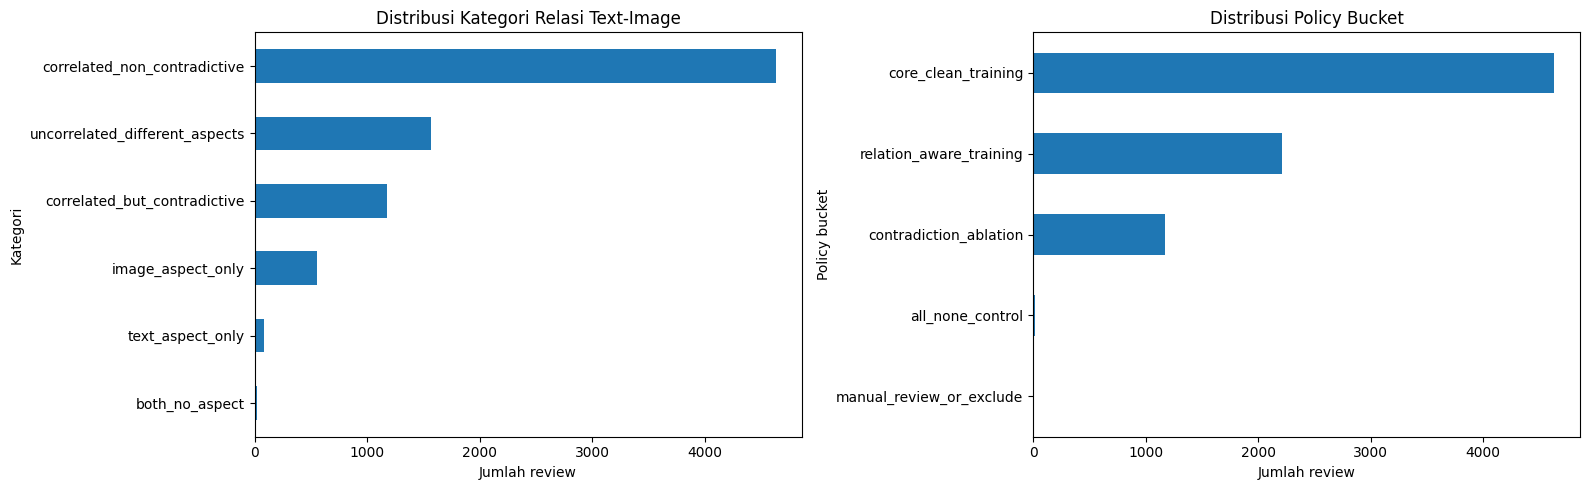

In [13]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    relation_counts.sort_values("count").plot(
        kind="barh",
        x="relation_category",
        y="count",
        ax=axes[0],
        legend=False,
        title="Distribusi Kategori Relasi Text-Image",
    )
    axes[0].set_xlabel("Jumlah review")
    axes[0].set_ylabel("Kategori")

    policy_bucket_counts = (
        review_relation["policy_bucket"]
        .value_counts()
        .rename_axis("policy_bucket")
        .reset_index(name="count")
    )
    policy_bucket_counts.sort_values("count").plot(
        kind="barh",
        x="policy_bucket",
        y="count",
        ax=axes[1],
        legend=False,
        title="Distribusi Policy Bucket",
    )
    axes[1].set_xlabel("Jumlah review")
    axes[1].set_ylabel("Policy bucket")

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Visualisasi dilewati karena error:", exc)

### 14. Ekspor Seluruh Hasil Analisis Relasi dan Policy ke CSV


In [14]:
review_output_columns = [
    "ID_Review", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "Text_Review",
    "image_count", "image_files_sample",
    *[f"text_{aspect}" for aspect in ASPECTS],
    *[f"image_{aspect}" for aspect in ASPECTS],
    "text_aspects", "image_aspects", "shared_aspects",
    "hard_contradiction_aspects", "soft_disagreement_aspects",
    "text_aspect_count", "image_aspect_count", "shared_aspect_count",
    "hard_contradiction_count", "soft_disagreement_count", "relation_overlap_ratio",
    "relation_category", "relation_strength", "policy_bucket",
    "recommended_fusion_strategy", "use_for_primary_training",
    "use_for_ablation", "needs_manual_review", "text_artifact_issue",
]

review_policy_output = review_relation[review_output_columns].copy()

review_policy_output.to_csv(OUTPUT_DIR / "review_level_relation_policy.csv", index=False, encoding="utf-8-sig")
image_level_policy.to_csv(OUTPUT_DIR / "image_level_relation_policy.csv", index=False, encoding="utf-8-sig")
aspect_relation.to_csv(OUTPUT_DIR / "aspect_level_relation_matrix.csv", index=False, encoding="utf-8-sig")
aspect_relation_counts.to_csv(OUTPUT_DIR / "aspect_relation_counts.csv", index=False, encoding="utf-8-sig")
relation_counts.to_csv(OUTPUT_DIR / "relation_category_counts.csv", index=False, encoding="utf-8-sig")
policy_summary.to_csv(OUTPUT_DIR / "policy_summary.csv", index=False, encoding="utf-8-sig")
manual_review_candidates.to_csv(OUTPUT_DIR / "manual_review_candidates.csv", index=False, encoding="utf-8-sig")
category_examples.to_csv(OUTPUT_DIR / "category_examples_for_manual_review.csv", index=False, encoding="utf-8-sig")

with open(OUTPUT_DIR / "relation_policy_summary.json", "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, ensure_ascii=False, indent=2)

def dataframe_to_markdown(df):
    # Minimal Markdown table writer without optional tabulate dependency.
    table = df.copy()
    table = table.fillna("")
    headers = [str(col) for col in table.columns]
    rows = [[str(value) for value in row] for row in table.to_numpy()]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)

policy_bucket_counts_md = (
    review_relation["policy_bucket"]
    .value_counts()
    .rename_axis("policy_bucket")
    .reset_index(name="count")
)

methodology_notes = f'''# Methodology Notes - Multimodal Relation Policy

## Dataset

- Text review rows: {dataset_summary['text_rows']}
- Unique text ID_Review: {dataset_summary['text_unique_ID_Review']}
- Image rows: {dataset_summary['image_rows']}
- Unique image ID_Review: {dataset_summary['image_unique_ID_Review']}
- Review-level policy rows: {dataset_summary['review_level_rows']}

## Dasar Metodologi

1. SemEval-2014 ABSA menekankan prediksi sentimen berdasarkan aspek, bukan sentimen umum.
2. MIMN memperkenalkan MABSA sebagai tugas yang memodelkan interaksi aspek, teks, dan gambar.
3. M2DF menunjukkan bahwa noisy atau text-unrelated images dapat mengganggu pembelajaran multimodal, sehingga perlu relation-aware policy.

## Taxonomy Relasi

{dataframe_to_markdown(relation_counts)}

## Policy Bucket

{dataframe_to_markdown(policy_bucket_counts_md)}

## Interpretasi

- `core_clean_training` digunakan sebagai data utama yang paling aman untuk multimodal training.
- `relation_aware_training` tetap dipertahankan karena mencerminkan kondisi nyata user-generated hotel review.
- `contradiction_ablation` digunakan untuk eksperimen khusus dan error analysis.
- `all_none_control` dapat dipakai sebagai kontrol semua aspek `None`, selama tidak ada artefak teks.
- `manual_review_or_exclude` perlu dicek manual atau dikeluarkan dari training final.
'''

with open(OUTPUT_DIR / "methodology_notes_for_thesis.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

print("Saved outputs to:", OUTPUT_DIR)
print("\nFiles:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Saved outputs to: /kaggle/working/mabsa_relation_policy_outputs

Files:
- aspect_level_relation_matrix.csv
- aspect_relation_counts.csv
- category_examples_for_manual_review.csv
- image_level_relation_policy.csv
- manual_review_candidates.csv
- methodology_notes_for_thesis.md
- policy_summary.csv
- relation_category_counts.csv
- relation_policy_summary.json
- review_level_relation_policy.csv


### 15. Verifikasi Akhir (Critical Checks) dan Status Kesimpulan


In [15]:
critical_checks = pd.DataFrame([
    {"check": "invalid_label_cells", "value": len(invalid_labels), "expected": 0},
    {"check": "review_policy_rows_match_text_rows", "value": len(review_policy_output), "expected": len(text_df)},
    {"check": "image_policy_rows_match_image_rows", "value": len(image_level_policy), "expected": len(image_df)},
    {"check": "aspect_relation_rows_match_review_x_7", "value": len(aspect_relation), "expected": len(text_df) * len(ASPECTS)},
])
critical_checks["status"] = np.where(critical_checks["value"] == critical_checks["expected"], "OK", "NEEDS_REVIEW")
display(critical_checks)

if (critical_checks["status"] == "NEEDS_REVIEW").any():
    print("Ada isu output yang perlu dicek sebelum lanjut Notebook 03.")
else:
    print("Notebook 02 selesai. Output policy siap dipakai untuk Notebook 03 final dataset builder.")

,check,value,expected,status
0,invalid_label_cells,0,0,OK
1,review_policy_rows_match_text_rows,8038,8038,OK
2,image_policy_rows_match_image_rows,17385,17385,OK
3,aspect_relation_rows_match_review_x_7,56266,56266,OK


Notebook 02 selesai. Output policy siap dipakai untuk Notebook 03 final dataset builder.
